# EL-GHALI MOHAMED

# Régression Linéaire Multiple
Implémentation  vectorisée.

In [1]:
# Importation des librairies nécessaires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Définition du Modèle
La fonction utilise le calcul matriciel pour plus de rapidité.

On ajoute une colonne de "1" à la matrice $X$. Cela permet de calculer le biais ($b$) en même temps que les poids ($W$), directement dans la matrice.

In [2]:
def multiple_lineare_regression(X, y, iterations, alpha):
    m = X.shape[0] # Nombre d'exemples (lignes) dans notre dataset

    #  on ajoute une colonne de 1 à X pour intégrer le calcul du biais directement dans la matrice
    colonne_un = np.ones((m, 1))
    X_b = np.hstack((colonne_un, X))

    # Nombre total de paramètres à trouver (caractéristiques + 1 pour le biais)
    n_caracteristiques = X_b.shape[1]

    # Initialisation de tous les poids (W) à zéro
    W = np.zeros((n_caracteristiques, 1))
    losses = [] # Liste pour stocker l'erreur à chaque étape

    for i in range(iterations):
        # 1. Prédictions : Produit matriciel pour calculer toutes les prédictions d'un coup
        y_pred = X_b @ W

        # 2. Calcul de l'erreur
        erreur = y_pred - y

        # 3. Calcul des gradients (version vectorisée pour la rapidité)
        gradients = (1/m) * (X_b.T @ erreur)

        # 4. Suivi de l'erreur globale (norme du vecteur d'erreur) pour vérifier la convergence
        losses.append(np.linalg.norm(erreur))

        # 5. Mise à jour des poids avec notre taux d'apprentissage (alpha)
        W -= alpha * gradients

    return W, losses

## 2. Création du Dataset
Création d'un jeu de 10 données factices  simulant des pannes serveurs. Les valeurs respectent une logique métier : une panne plus longue et affectant plus d'utilisateurs génère une perte financière ($Y$) plus importante.

In [3]:
# Dictionnaire contenant nos données fictives
data_dict = {
    "Downtime_Minutes": [10, 20, 15, 30, 45, 5, 60, 25, 40, 50],
    "Users_Affected": [100, 250, 150, 350, 500, 50, 700, 300, 450, 600],
    "Transactions": [500, 1000, 800, 1500, 2000, 200, 3000, 1200, 1800, 2500],
    "Data_Risk_Transactions_Lost": [5, 10, 8, 15, 20, 2, 30, 12, 18, 25],
    "Financial_Loss_INR": [5000, 12000, 8000, 18000, 25000, 2000, 35000, 15000, 22000, 30000]
}

# Conversion en DataFrame Pandas pour faciliter la manipulation
data = pd.DataFrame(data_dict)
data.head() # Affichage des 5 premières lignes pour vérifier

,Downtime_Minutes,Users_Affected,Transactions,Data_Risk_Transactions_Lost,Financial_Loss_INR
0,10,100,500,5,5000
1,20,250,1000,10,12000
2,15,150,800,8,8000
3,30,350,1500,15,18000
4,45,500,2000,20,25000


## 3. Entraînement et Visualisation
Extraction des données brutes.
**Paramètres :** Utilisation d'un $\alpha$ très faible (`1e-8`) pour empêcher l'erreur d'exploser.

Poids trouvés (W) :
 [[4.59555034e-03]
 [2.41148936e-01]
 [2.82581908e+00]
 [1.12683815e+01]
 [1.12683815e-01]]


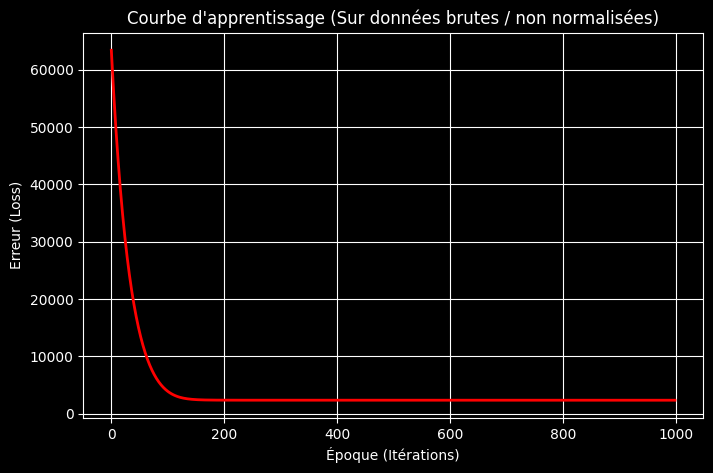

In [5]:
# Extraction des matrices de valeurs BRUTES
X = data[["Downtime_Minutes", "Users_Affected", "Transactions", "Data_Risk_Transactions_Lost"]].values
Y = data[["Financial_Loss_INR"]].values

# Entraînement du modèle (alpha = 1e-8 et 1 000 itérations)
W, losses = multiple_lineare_regression(X, Y, iterations=1000, alpha=1e-8)

# Affichage des poids finaux (le premier élément correspond au biais)
print("Poids trouvés (W) :\n", W)

# Tracé de la courbe de perte (Loss Curve)
plt.figure(figsize=(8, 5))
plt.plot(losses, color='red', linewidth=2)
plt.xlabel("Époque (Itérations)")
plt.ylabel("Erreur (Loss)")
plt.title("Courbe d'apprentissage (Sur données brutes / non normalisées)")
plt.grid(True)
plt.show()